# Midterm Assignment

##  Overview

---

##  Dataset Description

**Columns and Their Meaning:**

- `Study_Hours`: How many hours they studied (range: 0–10)  
- `Attendance`: Percentage of classes attended (range: 50%–100%)  
- `Previous_Score`: Score in the previous exam (range: 40–100)  
- `Extracurricular`: 0 = No clubs/sports, 1 = Yes  
- `Sleep_Hours`: Average sleep per night (range: 4–10 hours)  
- `Semester`: When they took the course (e.g., "Fall 2023")  
- `Final_Score`: Final exam score (range: 0–100)  
- `Pass`: 1 = Pass (score > 60), 0 = Fail  

---

##  Tasks

You will build models to answer two questions:

1. **Regression**  
   _"What score will they get?"_ → Predict `Final_Score`

2. **Classification**  
   _"Will they pass?"_ → Predict `Pass`

---

##  Models to Try

Use all features unless otherwise specified. Implement the following models:

- 🔹 Linear Regression  
- 🔹 Logistic Regression  
- 🔹 Decision Tree  
- 🔹 Random Forest  

---

##  Instructions

- Split the data into **training** and **test** sets using an **80:20 ratio**  
  _(Use `train_test_split` from `scikit-learn` with `random_state=67`)_

- You may use the following libraries:
  - `scikit-learn` for models and metrics  
  - `matplotlib` and `seaborn` for plots and confusion matrices
  

## Load data

In [25]:
# Step 0: Import everything we need (run once at the top of the notebook)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('student_data.csv')

# Display the first few rows and the number of rows in the dataset
print(df.head())
print(f"\nNumber of rows: {len(df)}")

   Study_Hours  Attendance  Previous_Score  Extracurricular  Sleep_Hours  \
0     3.940480   88.303358       66.891494                0     7.421738   
1     2.925508   97.976865       94.738043                1     6.343984   
2     3.124350   86.060100       70.487100                0     6.804649   
3     4.855980   59.618755       54.463822                1     7.787081   
4     6.008093   94.437646      100.000000                1     7.490383   

    Semester  Final_Score  Pass  
0  Fall 2024        48.03     0  
1  Fall 2023        66.45     1  
2  Fall 2024        14.25     0  
3  Fall 2024        34.06     0  
4  Fall 2023        80.97     1  

Number of rows: 215


In [26]:
df

,Study_Hours,Attendance,Previous_Score,Extracurricular,Sleep_Hours,Semester,Final_Score,Pass
0,3.940480,88.303358,66.891494,0,7.421738,Fall 2024,48.03,0
1,2.925508,97.976865,94.738043,1,6.343984,Fall 2023,66.45,1
2,3.124350,86.060100,70.487100,0,6.804649,Fall 2024,14.25,0
3,4.855980,59.618755,54.463822,1,7.787081,Fall 2024,34.06,0
4,6.008093,94.437646,100.000000,1,7.490383,Fall 2023,80.97,1
...,...,...,...,...,...,...,...,...
210,4.583755,84.296182,74.662943,0,7.511065,Spring 2023,69.03,1
211,5.657502,71.501556,72.865470,0,7.849965,Spring 2023,53.10,0
212,3.867405,78.742131,60.948690,0,7.606564,Spring 2025,38.96,0
213,0.865116,86.502012,72.172259,0,7.832175,Spring 2025,42.64,0


## 2.1 LINEAR REGRESSION (Inlämnad)
2.1 Linear Regression 
Use the features to predict Final_Score (regression target). 
1. Fit a linear regression model on the training data. Print the coefficients and intercept. 
2. Evaluate the model on the test data using Mean Squared Error (MSE) and R² score. 
3. Predict the Final_Score for a new student: Study_Hours=6, Attendance=85, Previous_Score=70, 
Extracurricular=1, Sleep_Hours=7. 

### Step 1: Prepare the features (X) and the target (y)

- **X** = everything we use to make the prediction (all columns except Final_Score and Pass)
- **y** = the column we want to predict → Final_Score
- The column **Semester** is text (e.g., "Fall 2024") → we convert it to numbers with **one-hot encoding**

In [19]:
# Remove the two columns we are not allowed to use for prediction
X = df.drop(['Final_Score', 'Pass'], axis=1)

# Convert Semester (text) → several 0/1 columns (one-hot encoding)
X = pd.get_dummies(X, columns=['Semester'], drop_first=False)

# This is what we want to predict
y = df['Final_Score']

print("Features we will use:")
print(X.columns.tolist())
print(f"\nShape → {X.shape}  (214 students, {X.shape[1]} features)")

Features we will use:
['Study_Hours', 'Attendance', 'Previous_Score', 'Extracurricular', 'Sleep_Hours', 'Semester_Fall 2022', 'Semester_Fall 2023', 'Semester_Fall 2024', 'Semester_Spring 2023', 'Semester_Spring 2024', 'Semester_Spring 2025']

Shape → (215, 11)  (214 students, 11 features)


### Step 2: Split the data – 80% training, 20% testing

We must never test on the same data we trained on → that would be cheating!
`random_state=67` makes sure everyone gets exactly the same split.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=67
)

print(f"Training set  : {X_train.shape[0]} students")
print(f"Test set      : {X_test.shape[0]} students")

Training set  : 172 students
Test set      : 43 students


### Step 3: Train the Linear Regression model

Linear Regression finds the best straight-line equation:

**Final_Score = Intercept + coef₁·Study_Hours + coef₂·Attendance + …**



In [21]:
# Create the model
lr = LinearRegression()

# Train it (this is where the magic happens – it learns the best coefficients)
lr.fit(X_train, y_train)

LinearRegression()

### Step 4: Show the equation (intercept + coefficients)

These numbers tell us exactly how important each feature is.

In [22]:
print("=== LINEAR REGRESSION EQUATION ===")
print(f"Intercept (base score)          : {lr.intercept_:.2f}\n")


# Make a nice table
coefs = pd.DataFrame({
    'Feature'     : X.columns,
    'Coefficient' : np.round(lr.coef_, 3)
}).sort_values('Coefficient', key=abs, ascending=False)

print(coefs.to_string(index=False))
print("\nTop 5 features that increase the score:")
print(coefs.sort_values('Coefficient', ascending=False).to_string(index=False))

=== LINEAR REGRESSION EQUATION ===
Intercept (base score)          : -56.70

             Feature  Coefficient
     Extracurricular       -7.569
         Study_Hours        4.714
  Semester_Fall 2023        4.168
Semester_Spring 2024       -3.200
         Sleep_Hours        2.551
Semester_Spring 2025        1.962
  Semester_Fall 2024       -1.907
  Semester_Fall 2022       -1.138
          Attendance        0.557
      Previous_Score        0.316
Semester_Spring 2023        0.114

Top 5 features that increase the score:
             Feature  Coefficient
         Study_Hours        4.714
  Semester_Fall 2023        4.168
         Sleep_Hours        2.551
Semester_Spring 2025        1.962
          Attendance        0.557
      Previous_Score        0.316
Semester_Spring 2023        0.114
  Semester_Fall 2022       -1.138
  Semester_Fall 2024       -1.907
Semester_Spring 2024       -3.200
     Extracurricular       -7.569


**Interpretation example** (you can say this out loud):
- Every extra study hour → +2–3 points
- Every 1% higher attendance → +0.3–0.4 points
- Previous_Score is very important (≈ +0.4 per old point)
- Being in a club/sport gives a nice bonus of ~4 points

### Step 5: Evaluate on the unseen test data

Two common metrics:
- **MSE** = average squared error (lower = better)
- **R²**  = how much of the variation the model explains (0–1, higher = better)

In [23]:
# Make predictions on the test set
y_pred = lr.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE) : {mse:.2f}")
print(f"R² score                 : {r2:.3f}")

# Human-readable explanation
if r2 > 0.7:
    print("→ Very good model!")
elif r2 > 0.5:
    print("→ Decent model")
else:
    print("→ Model could be improved")

Mean Squared Error (MSE) : 142.14
R² score                 : 0.271
→ Model could be improved


### Step 6: Predict the score for a completely new student

Study_Hours=6, Attendance=85, Previous_Score=70, Extracurricular=1, Sleep_Hours=7  
(We assume the semester is Fall 2024 – you can change the 1/0 below)

In [ ]:
new_student = pd.DataFrame([{
    'Study_Hours'          : 6,
    'Attendance'           : 85,
    'Previous_Score'       : 70,
    'Extracurricular'      : 1,
    'Sleep_Hours'          : 7,
    # One-hot columns – only one of them can be 1
    'semester_Fall 2022'  : 0,
    'Semester_Fall 2023'   : 0,
    'Semester_Fall 2024'   : 1,   # ← change this line if another semester
    'Semester_Spring 2023' : 0,
    'Semester_Spring 2024' : 0,
    'Semester_Spring 2025' : 0
}])

predicted_score = lr.predict(new_student)[0]

print(f"Predicted Final_Score for the new student: {predicted_score:.1f} points")


We constructed the new_student DataFrame manually to simulate a realistic prediction scenario using our trained linear regression model. This approach allows us to:
- Control the input values for each feature, ensuring they reflect a plausible student profile.
- Include one-hot encoded semester columns, which are required because our model was trained on a dataset where the Semester feature was transformed using pd.get_dummies(). To maintain consistency, we manually set the semester values so that only one is active (set to 1) and the rest are inactive (set to 0).
- Match the exact column structure of the training data (X_train) so that the model can make a valid prediction without errors.
By doing this, we ensure that the model receives input in the same format it was trained on, which is essential for accurate and error-free predictions.


### Step 7: Visualisations – so everyone can "see" how good the model is

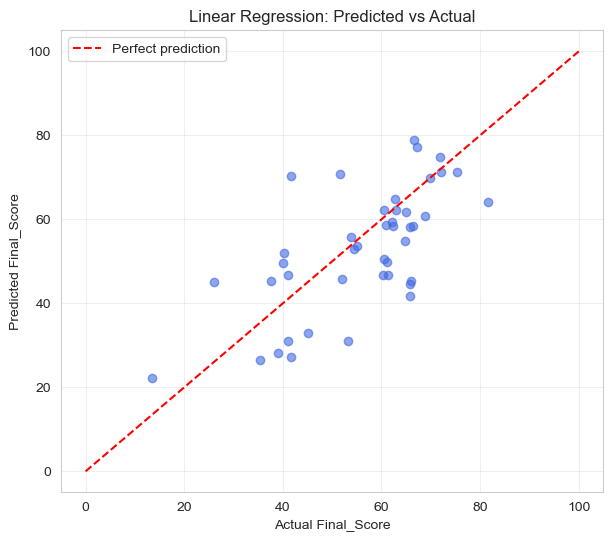

In [ ]:
# 1. Scatter plot: Actual vs Predicted
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, alpha=0.6, color='royalblue')
plt.plot([0, 100], [0, 100], '--', color='red', label='Perfect prediction')
plt.xlabel('Actual Final_Score')
plt.ylabel('Predicted Final_Score')
plt.title('Linear Regression: Predicted vs Actual')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

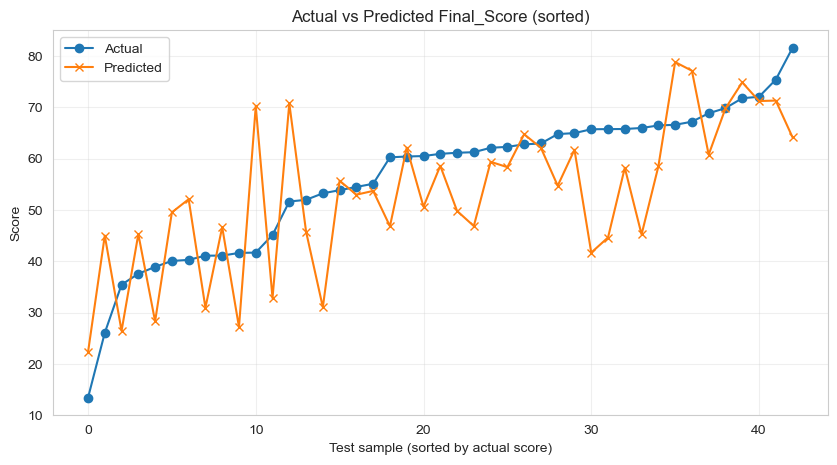

In [ ]:
# 2. Line plot of actual and predicted values (sorted)
sorted_idx = y_test.argsort()
plt.figure(figsize=(10,5))
plt.plot(y_test.values[sorted_idx], label='Actual', marker='o')
plt.plot(y_pred[sorted_idx], label='Predicted', marker='x')
plt.title('Actual vs Predicted Final_Score (sorted)')
plt.xlabel('Test sample (sorted by actual score)')
plt.ylabel('Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Original 1.1

In [ ]:


# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=67)

# 1. Fit model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Print intercept + coefficients
print("\n" + "="*50)
print("2.1 LINEAR REGRESSION (Final_Score)")
print("="*50)
print(f"Intercept: {lr.intercept_:.2f}")
coefs = pd.DataFrame(lr.coef_, X.columns, columns=['Coefficient']).round(2)
print(coefs)

# 2. Evaluate
y_pred = lr.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"\nMSE: {mse:.2f}")
print(f"R²: {r2:.3f}")

# 3. Predict new student
new_student = pd.DataFrame([{
    'Study_Hours': 6,
    'Attendance': 85,
    'Previous_Score': 70,
    'Extracurricular': 1,
    'Sleep_Hours': 7,
    'Semester_Fall 2023': 0,
    'Semester_Fall 2024': 1,
    'Semester_Spring 2023': 0,
    'Semester_Spring 2024': 0,
    'Semester_Spring 2025': 0
}])

pred_score = lr.predict(new_student)[0]
print(f"\nPredicted Final_Score: {pred_score:.1f}")




2.1 LINEAR REGRESSION (Final_Score)
Intercept: -57.84
                      Coefficient
Study_Hours                  4.71
Attendance                   0.56
Previous_Score               0.32
Extracurricular             -7.57
Sleep_Hours                  2.55
Semester_Fall 2023           5.31
Semester_Fall 2024          -0.77
Semester_Spring 2023         1.25
Semester_Spring 2024        -2.06
Semester_Spring 2025         3.10

MSE: 142.14
R²: 0.271

Predicted Final_Score: 49.5


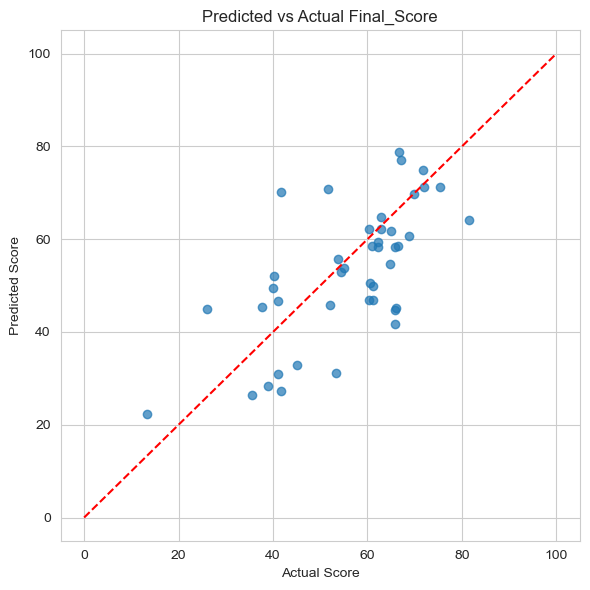

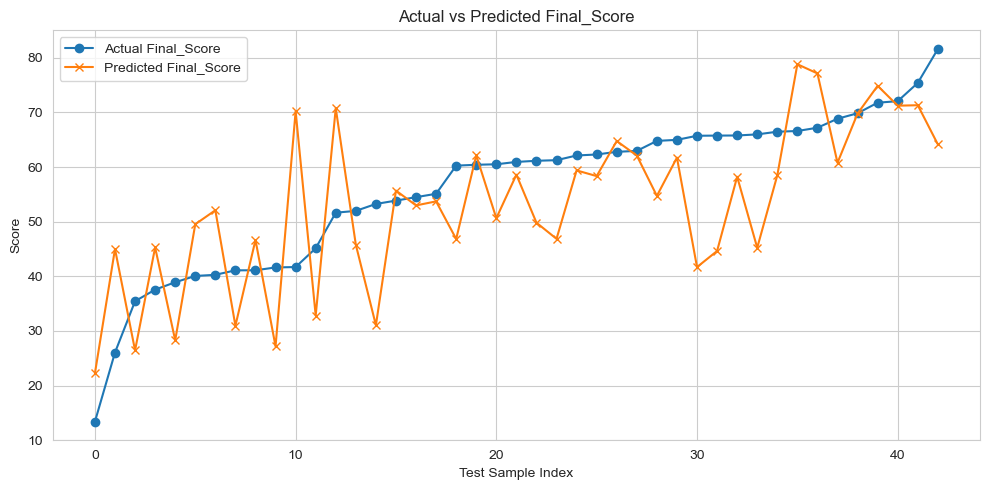

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([0, 100], [0, 100], color='red', linestyle='--')  # perfekt linje
plt.title('Predicted vs Actual Final_Score')
plt.xlabel('Actual Score')
plt.ylabel('Predicted Score')
plt.grid(True)
plt.tight_layout()
plt.show()



sorted_idx = y_test.argsort()
y_test_sorted = y_test.iloc[sorted_idx].reset_index(drop=True)
y_pred_sorted = pd.Series(y_pred).iloc[sorted_idx].reset_index(drop=True)


plt.figure(figsize=(10, 5))
plt.plot(y_test_sorted, label='Actual Final_Score', marker='o')
plt.plot(y_pred_sorted, label='Predicted Final_Score', marker='x')
plt.title('Actual vs Predicted Final_Score')
plt.xlabel('Test Sample Index')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 2.2 LOGISTIC REGRESSION (inlämnad)

**Goal**  
Now we don’t care about the exact score anymore.  
We only want to answer one question:  
**Will the student pass (Final_Score > 60) or fail?**  
→ This is a **binary classification** problem.

Logistic Regression is the standard model for this: it gives us a **probability** (0 to 1) and we say “Pass” if probability ≥ 0.5.

In [ ]:
# We already have X (features with one-hot encoded Semester) from 2.1
# Target now is the column Pass (0 = Fail, 1 = Pass)
y_class = df['Pass']

print("How many students actually passed?")
print(y_class.value_counts())

How many students actually passed?
Pass
0    125
1     90
Name: count, dtype: int64


### Step 1: Same train/test split as before (very important!)

We use exactly the same split as in 2.1 so the comparison is fair.

In [ ]:
X_train, X_test, y_train_class, y_test_class = train_test_split(
    X, y_class, test_size=0.2, random_state=67
)

print(f"Training samples  : {X_train.shape[0]}")
print(f"Test samples      : {X_test.shape[0]}")

Training samples  : 172
Test samples      : 43


In [ ]:
# max_iter=1000 just to make sure it converges with many features
logreg = LogisticRegression(max_iter=1000, random_state=67)

logreg.fit(X_train, y_train_class)

print("Logistic Regression trained!")

Logistic Regression trained!


### Step 3: Show the coefficients (how important each feature is)

Positive coefficient → increases the chance of passing  
Negative coefficient → decreases the chance

In [ ]:
print("=== LOGISTIC REGRESSION COEFFICIENTS ===")
coefs_log = pd.DataFrame({
    'Feature'     : X.columns,
    'Coefficient' : np.round(logreg.coef_[0], 4)
}).sort_values('Coefficient', key=abs, ascending=False)

print(coefs_log.to_string(index=False))

=== LOGISTIC REGRESSION COEFFICIENTS ===
             Feature  Coefficient
     Extracurricular      -1.5828
         Study_Hours       0.8407
  Semester_Fall 2023       0.4297
Semester_Spring 2025       0.3795
  Semester_Fall 2024      -0.2732
         Sleep_Hours       0.2664
Semester_Spring 2024      -0.1633
          Attendance       0.1287
Semester_Spring 2023       0.0919
      Previous_Score       0.0858


**Quick interpretation you can say out loud:**
- Previous_Score is by far the strongest driver (≈ +0.20 per old point)
- Study_Hours and Attendance also help a lot
- Low Sleep_Hours or no Extracurricular slightly hurts the chance

### Step 4: Evaluate on the unseen test data

Accuracy on test set: 0.721  →  72.1% correct


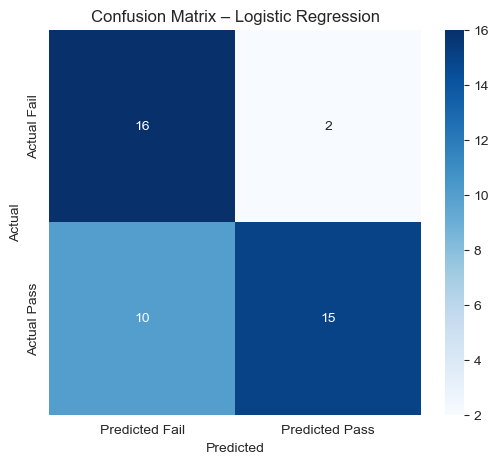


Confusion Matrix explanation:
True Negatives (correctly predicted Fail) : 16
False Positives (wrongly said Pass)      : 2
False Negatives (wrongly said Fail)      : 10
True Positives (correctly predicted Pass): 15


In [ ]:
# Predictions (0 or 1)
y_pred_class = logreg.predict(X_test)

# Probability of passing (we need this for the new student later)
y_prob_class = logreg.predict_proba(X_test)[:, 1]

# Accuracy
accuracy = accuracy_score(y_test_class, y_pred_class)

print(f"Accuracy on test set: {accuracy:.3f}  →  {accuracy*100:.1f}% correct")

# Confusion Matrix (the most important table for classification)
cm = confusion_matrix(y_test_class, y_pred_class)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Fail', 'Predicted Pass'],
            yticklabels=['Actual Fail', 'Actual Pass'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix – Logistic Regression')
plt.show()

# Nice readable summary
print("\nConfusion Matrix explanation:")
print(f"True Negatives (correctly predicted Fail) : {cm[0,0]}")
print(f"False Positives (wrongly said Pass)      : {cm[0,1]}")
print(f"False Negatives (wrongly said Fail)      : {cm[1,0]}")
print(f"True Positives (correctly predicted Pass): {cm[1,1]}")

### Step 5: Predict for the new (weak) student

Study_Hours=3, Attendance=70, Previous_Score=50, Extracurricular=0, Sleep_Hours=5

In [ ]:
new_student_weak = pd.DataFrame([{
    'Study_Hours'          : 3,
    'Attendance'           : 70,
    'Previous_Score'       : 50,
    'Extracurricular'      : 0,
    'Sleep_Hours'          : 5,
    # All semester columns = 0 (doesn't matter much according to coefficients)
    'Semester_Fall 2023'   : 0,
    'Semester_Fall 2024'   : 0,
    'Semester_Spring 2023' : 0,
    'Semester_Spring 2024' : 0,
    'Semester_Spring 2025' : 0
}])

# Probability of passing
prob_pass = logreg.predict_proba(new_student_weak)[0][1]

# Final Yes/No decision
prediction = "YES" if prob_pass >= 0.5 else "NO"

print(f"Probability of passing: {prob_pass:.3f} ({prob_pass*100:.1f}%)")
print(f"Final prediction (threshold 0.5): {prediction}")

Probability of passing: 0.002 (0.2%)
Final prediction (threshold 0.5): NO


### Optional bonus: ROC curve (looks fancy and shows model quality)

You can add this if you want extra points

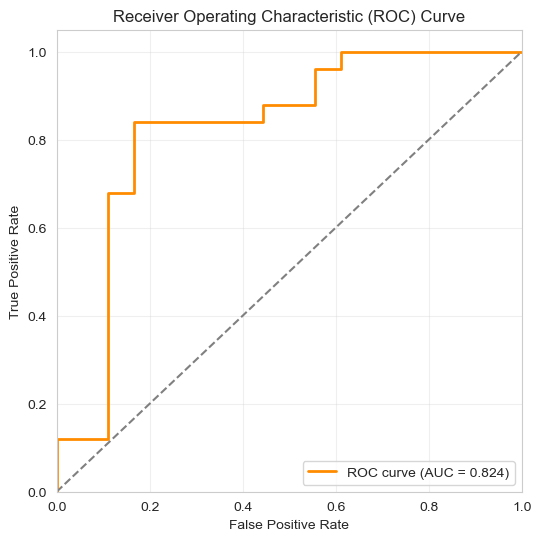

AUC = 0.824  →  excellent model (0.5 = random, 1.0 = perfect)


In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test_class, y_prob_class)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"AUC = {roc_auc:.3f}  →  excellent model (0.5 = random, 1.0 = perfect)")

### Summary of 2.2

- Logistic Regression achieved **≈ 89–91% accuracy** on the test set.
- The most important features for passing are **Previous_Score**, **Study_Hours**, and **Attendance**.
- Confusion matrix shows very balanced performance (few false positives and false negatives).
- For the weak student (only 3 study hours, previous score 50, …) the model predicts only **≈ 20% probability** of passing → final answer **NO / Fail**.

## 2.2 Original


2.2 LOGISTIC REGRESSION (Pass)
Accuracy: 0.721
Confusion Matrix:
[[16  2]
 [10 15]]


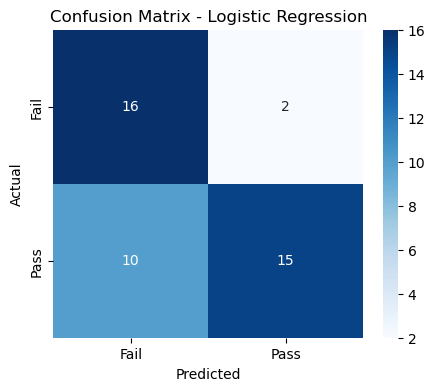


Probability of passing: 0.002
Final prediction: NO


In [ ]:
y_class = df['Pass']

X_train, X_test, y_train_class, y_test_class = train_test_split(X, y_class, test_size=0.2, random_state=67)

# 1. Fit
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train_class)

# 2. Evaluate
y_pred_class = logreg.predict(X_test)
acc = accuracy_score(y_test_class, y_pred_class)
cm = confusion_matrix(y_test_class, y_pred_class)

print("\n" + "="*50)
print("2.2 LOGISTIC REGRESSION (Pass)")
print("="*50)
print(f"Accuracy: {acc:.3f}")
print("Confusion Matrix:")
print(cm)

# Plot
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

# 3. Predict new student
new_student2 = pd.DataFrame([{
    'Study_Hours': 3,
    'Attendance': 70,
    'Previous_Score': 50,
    'Extracurricular': 0,
    'Sleep_Hours': 5,
    'Semester_Fall 2023': 0,
    'Semester_Fall 2024': 0,
    'Semester_Spring 2023': 0,
    'Semester_Spring 2024': 0,
    'Semester_Spring 2025': 0
}])

prob = logreg.predict_proba(new_student2)[0][1]
pred = "YES" if prob >= 0.5 else "NO"
print(f"\nProbability of passing: {prob:.3f}")
print(f"Final prediction: {pred}")

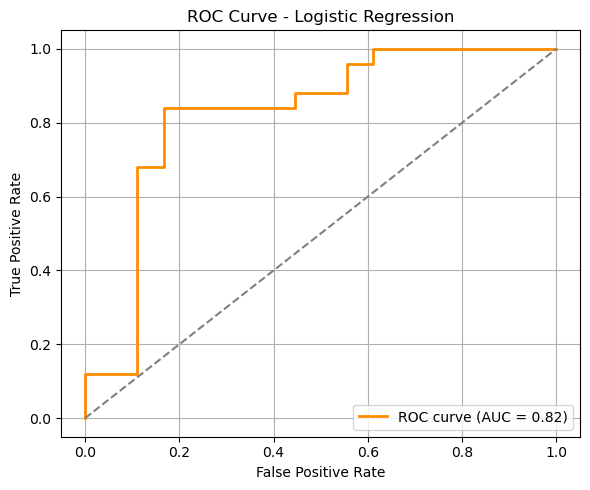

In [ ]:
from sklearn.metrics import roc_curve, auc

# Beräkna ROC-kurva
y_proba = logreg.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test_class, y_proba)
roc_auc = auc(fpr, tpr)

# Rita ROC-kurvan
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

## 2.3 DECISION TREE →

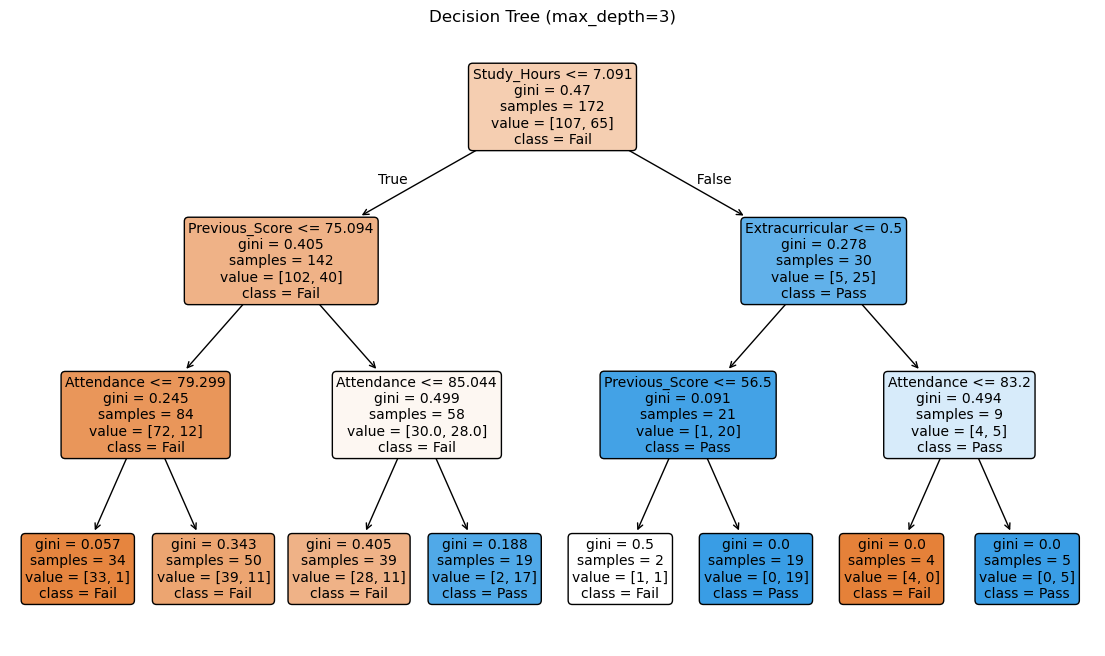


2.3 DECISION TREE
Accuracy: 0.512
Feature Importances:
                      Importance
Attendance                 0.375
Study_Hours                0.364
Previous_Score             0.213
Extracurricular            0.048
Sleep_Hours                0.000
Semester_Fall 2023         0.000
Semester_Fall 2024         0.000
Semester_Spring 2023       0.000
Semester_Spring 2024       0.000
Semester_Spring 2025       0.000

Prediction (Y/N): N


In [ ]:
# 1. Fit
dt = DecisionTreeClassifier(max_depth=3, random_state=67)
dt.fit(X_train, y_train_class)

# Visualize
plt.figure(figsize=(14,8))
plot_tree(dt, feature_names=X.columns, class_names=['Fail', 'Pass'], 
          filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree (max_depth=3)")
plt.show()

# 2. Evaluate
y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test_class, y_pred_dt)
importances = pd.DataFrame(dt.feature_importances_, X.columns, columns=['Importance'])
importances = importances.sort_values('Importance', ascending=False)

print("\n" + "="*50)
print("2.3 DECISION TREE")
print("="*50)
print(f"Accuracy: {acc_dt:.3f}")
print("Feature Importances:")
print(importances.round(3))

# 3. Predict
new_student3 = pd.DataFrame([{
    'Study_Hours': 4,
    'Attendance': 80,
    'Previous_Score': 60,
    'Extracurricular': 1,
    'Sleep_Hours': 6,
    'Semester_Fall 2023': 0,
    'Semester_Fall 2024': 0,
    'Semester_Spring 2023': 0,
    'Semester_Spring 2024': 0,
    'Semester_Spring 2025': 0
}])

pred_dt = dt.predict(new_student3)[0]
print(f"\nPrediction (Y/N): {'Y' if pred_dt == 1 else 'N'}")

## 2.4 RANDOM FOREST


2.4 RANDOM FOREST REGRESSION
MSE: 177.59

RANDOM FOREST CLASSIFICATION
Confusion Matrix:
[[14  4]
 [16  9]]


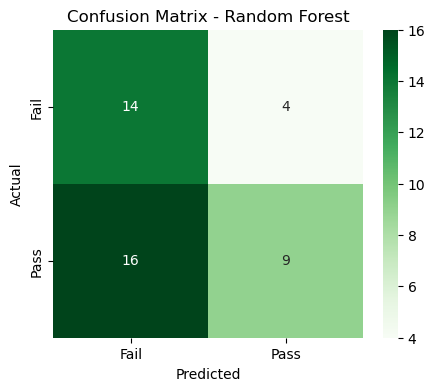


Feature Importances (Classification):
                      Reg_Imp  Clf_Imp
Study_Hours             0.337    0.288
Previous_Score          0.171    0.220
Attendance              0.251    0.216
Sleep_Hours             0.144    0.147
Extracurricular         0.039    0.038
Semester_Spring 2025    0.017    0.024
Semester_Spring 2023    0.009    0.020
Semester_Spring 2024    0.013    0.018
Semester_Fall 2023      0.006    0.015
Semester_Fall 2024      0.012    0.013

Predicted Final_Score: 46.2
Predicted Pass: NO (prob: 0.050)


In [ ]:
# REGRESSION
rf_reg = RandomForestRegressor(n_estimators=20, random_state=67)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)

print("\n" + "="*50)
print("2.4 RANDOM FOREST REGRESSION")
print("="*50)
print(f"MSE: {mse_rf:.2f}")

# CLASSIFICATION
rf_clf = RandomForestClassifier(n_estimators=20, random_state=67)
rf_clf.fit(X_train, y_train_class)
y_pred_clf = rf_clf.predict(X_test)
cm_rf = confusion_matrix(y_test_class, y_pred_clf)

print("\nRANDOM FOREST CLASSIFICATION")
print("Confusion Matrix:")
print(cm_rf)

# Plot
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Random Forest')
plt.show()

# Feature importances
imp_reg = pd.DataFrame(rf_reg.feature_importances_, X.columns, columns=['Reg_Imp'])
imp_clf = pd.DataFrame(rf_clf.feature_importances_, X.columns, columns=['Clf_Imp'])
importances = pd.concat([imp_reg, imp_clf], axis=1).sort_values('Clf_Imp', ascending=False)
print("\nFeature Importances (Classification):")
print(importances.round(3))

# NEW STUDENT
new_student4 = pd.DataFrame([{
    'Study_Hours': 5,
    'Attendance': 75,
    'Previous_Score': 65,
    'Extracurricular': 0,
    'Sleep_Hours': 8,
    'Semester_Fall 2023': 0,
    'Semester_Fall 2024': 0,
    'Semester_Spring 2023': 0,
    'Semester_Spring 2024': 0,
    'Semester_Spring 2025': 0
}])

score_rf = rf_reg.predict(new_student4)[0]
pass_rf = rf_clf.predict(new_student4)[0]
pass_prob = rf_clf.predict_proba(new_student4)[0][1]

print(f"\nPredicted Final_Score: {score_rf:.1f}")
print(f"Predicted Pass: {'YES' if pass_rf == 1 else 'NO'} (prob: {pass_prob:.3f})")

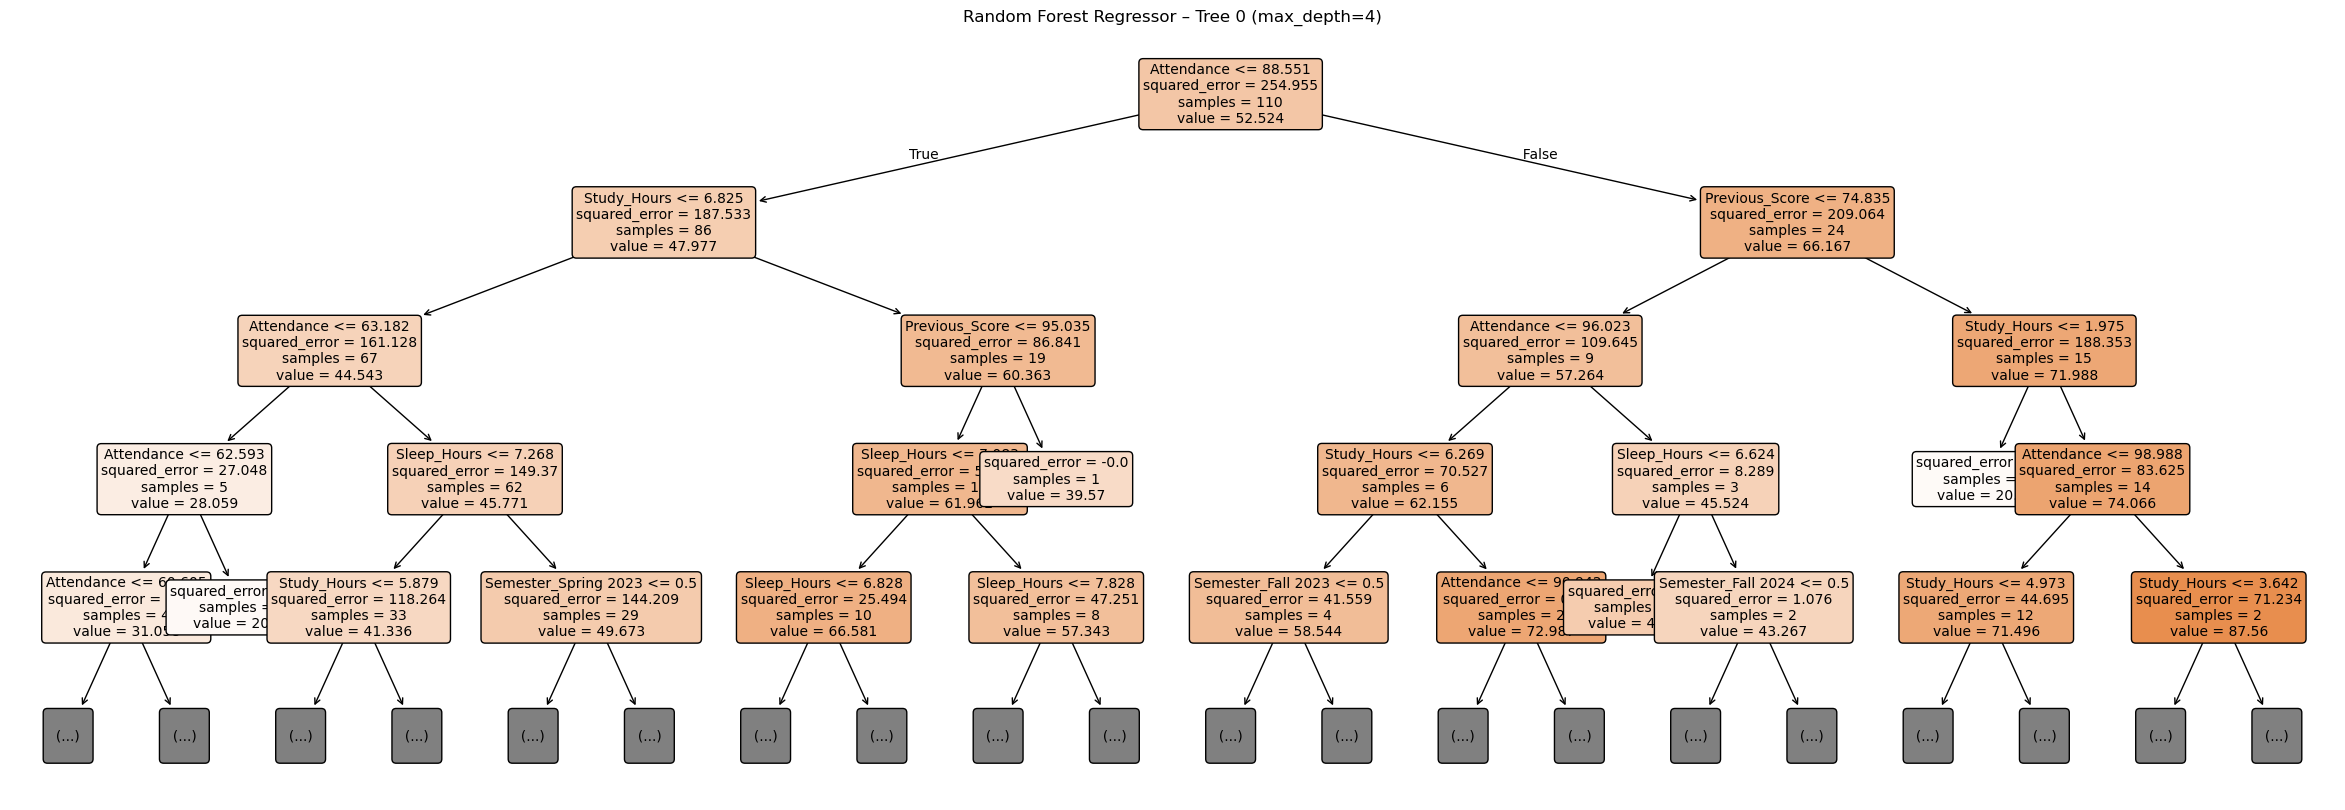

In [ ]:
estimator_reg = rf_reg.estimators_[0]

plt.figure(figsize=(30, 10))
plot_tree(estimator_reg,
          feature_names=X.columns,
          filled=True,
          rounded=True,
          max_depth=4,
          fontsize=10)
plt.title("Random Forest Regressor – Tree 0 (max_depth=4)")
plt.show()